# Project Proposal by Isaac Marr

# CSCI S-108

# Summer 2025

# Summary
According to [The Athletic](https://www.nytimes.com/athletic/5377539/2024/03/29/odds-a-top-10-qb-busts-scoop-city/), 41% of Quarterbacks drafted in the first round of the NFL Draft can be classified as a reach or a bust. Quarterback is the most important position in football, and NFL teams pay handsomely for good ones with top QBs making more than $50 million per year according to [Spotrac](https://www.spotrac.com/nfl/rankings/player/_/year/2024/position/qb/sort/contract_average). Even a mediocre quarterback is often the "face of the franchise" as long as he is playing, and the drafting of a new quarterback is always a momentous occasion for the fanbase. Multi-billion dollar companies like NFL teams rarely make decisions based on a coin flip, but drafting a good quarterback has only slightly better odds. A solid quarterback can boost ticket and merchandise sales, a great one can bring a Super Bowl and even shift the financial fortunes of his host city. With this project, I will take a look at every quarterback who played a college snap from 2004 until 2020 and track their college stats, NFL Combine workout data, draft position, and NFL success. Using this data, I will develop similarity measures to compare future potential draft picks to past players. I will also explore cluster analysis to see which traits generally lead to NFL success.

# Data
I am using three datasets that I have merged for this project.

1. I used the [cfbfastR](https://cfbfastr.sportsdataverse.org) R package to get a dataset with the stats of every college quarterback who registered a statistic between 2004 (the earliest year that the package can return) to 2020. I chose 2020 because I wanted a minumum of four seasons of NFL data to study outcomes.
2. I used the [nflreadr](https://nflreadr.nflverse.com/reference/index.html) R package to get NFL combine data from 2000 to 2025.
3. I used the [Pro Football Reference](https://www.pro-football-reference.com) StatHead draft tools to generate a spreadsheet containing every NFL quarterback who entered the league between 2005 and 2021 with their draft position and some statistics. I am using Football Reference's AV metric as a way to judge career quality. You can read about that metric [here](https://www.pro-football-reference.com/about/approximate_value.htm).

In [268]:
import pandas as pd
import numpy as np
import string
import matplotlib.pyplot as plt

# Loading the Datasets

In [270]:
results_df = pd.read_excel("NFL Results Data.xlsx")
cfb_df = pd.read_csv("cfb_qb_stats_full_2004_2020.csv")
combine_df = pd.read_csv("combine_data.csv")

# Cleaning the NFL Data

In [272]:
results_df["years_played"] = results_df["To"] - results_df["From"] + 1 # Calculating years played in career
results_df["av_per_year"] = results_df["AV"] / results_df["years_played"] # calculating AV/year for possible future use
results_df = results_df.drop(["Rk", "AV.1", "Pos"], axis=1) # Dropping redundant/unecessary columns
print(results_df.shape)
results_df.head(10)

(212, 15)


,Player,AV,Draft Team,Round,Pick,Draft Year,College,From,To,Age,G,GS,Team,years_played,av_per_year
0,Aaron Rodgers,243,GNB,1,24,2005,California,2005,2024,22-41,248,241,"GNB,NYJ",20,12.150000
1,Alex Smith,120,SFO,1,1,2005,Utah,2005,2020,21-36,174,167,"KAN,SFO,WAS",16,7.500000
2,Ryan Fitzpatrick,101,STL,7,250,2005,Harvard,2005,2021,23-39,166,147,"BUF,CIN,HOU,MIA,NYJ,STL,TAM,TEN,WAS",17,5.941176
3,Matt Cassel,51,NWE,7,230,2005,Southern California,2005,2018,23-36,107,81,"BUF,DAL,DET,KAN,MIN,NWE,TEN",14,3.642857
4,Kyle Orton,44,CHI,4,106,2005,Purdue,2005,2014,23-32,87,82,"BUF,CHI,DAL,DEN,KAN",10,4.400000
5,Seneca Wallace,16,SEA,4,110,2003,Iowa State,2005,2013,25-33,64,22,"CLE,GNB,SEA",9,1.777778
6,Charlie Frye,8,CLE,3,67,2005,Akron,2005,2009,24-28,26,23,"CLE,OAK,SEA",5,1.600000
7,Dan Orlovsky,7,DET,5,145,2005,Connecticut,2005,2015,22-32,26,12,"DET,HOU,IND,TAM",11,0.636364
8,Matt Mauck,1,DEN,7,225,2004,Louisiana State,2005,2005,26,2,1,TEN,1,1.000000
9,Kliff Kingsbury,0,NWE,6,201,2003,Texas Tech,2005,2005,26,1,0,NYJ,1,0.000000


# Cleaning the College Data

In [274]:
# Dropping unecessary college columns
cfb_df = cfb_df.drop(['year','passing_pct', 'passing_ypa','rushing_ypc',
       'receiving_rec', 'receiving_yds', 'receiving_td', 'receiving_ypr',
       'receiving_long', 'fumbles_rec','defensive_solo', 'defensive_tot', 'defensive_tfl', 'defensive_sacks',
       'defensive_qb_hur', 'interceptions_int', 'interceptions_yds',
       'interceptions_avg', 'interceptions_td', 'defensive_pd', 'defensive_td',
       'kicking_fgm', 'kicking_fga', 'kicking_pct', 'kicking_xpa',
       'kicking_xpm', 'kicking_pts', 'kicking_long', 'kick_returns_no',
       'kick_returns_yds', 'kick_returns_avg', 'kick_returns_td',
       'kick_returns_long', 'punting_no', 'punting_yds', 'punting_ypp',
       'punting_long', 'punting_in_20', 'punting_tb', 'punt_returns_no',
       'punt_returns_yds', 'punt_returns_avg', 'punt_returns_td',
       'punt_returns_long', 'position', 'stat_category'], axis=1)
print(cfb_df.shape)
cfb_df.head(10)

(10350, 16)


,team,conference,athlete_id,player,passing_completions,passing_att,passing_yds,passing_td,passing_int,rushing_car,rushing_yds,rushing_td,rushing_long,fumbles_fum,fumbles_lost,season
0,Memphis,Conference USA,162068,Will Hudgens,33.0,62.0,413.0,3.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2005
1,Ohio,Mid-American,170810,Brandon Jones,11.0,35.0,124.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2005
2,San José State,Western Athletic,176754,Chad Bozzo,13.0,33.0,155.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2005
3,Pittsburgh,Big East,173548,Bill Stull,1.0,2.0,17.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2005
4,Kent State,Mid-American,170641,Jon Brown,60.0,97.0,474.0,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,2005
5,Western Michigan,Mid-American,170735,Tim Hiller,98.0,150.0,1334.0,20.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,2005
6,Memphis,Conference USA,162068,Will Hudgens,2.0,4.0,14.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2006
7,Oregon State,Pac-10,168823,Sean Canfield,28.0,45.0,335.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2006
8,Wake Forest,ACC,169067,Brett Hodges,2.0,2.0,24.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2006
9,Wake Forest,ACC,169077,Riley Skinner,150.0,227.0,1780.0,8.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,2006


In [275]:
# College data is by season, not college career, need to aggregate by player to get career data
# Aggregating seasons played to display first and last year of career
college_seasons = cfb_df.groupby("athlete_id", as_index=False).agg(from_year=("season", "min"),to_year=("season", "max"))
# Aggregating teams played for to allow for multiple teams
team_list = cfb_df.groupby("athlete_id")["team"].agg(lambda x: ", ".join(sorted(set(x)))).reset_index() #See Citation 1
# Aggregating conferences played for to allow for multiple conferences
conference_list = cfb_df.groupby("athlete_id")["conference"].agg(lambda x: ", ".join(sorted(set(x)))).reset_index()
# Grouping the statistical data by summing across seasons to get career totals.
career_stats = cfb_df.groupby("athlete_id", as_index=False).agg({
    "player": "last",
    "passing_completions": "sum",
    "passing_att": "sum",
    "passing_yds": "sum",
    "passing_td": "sum",
    "passing_int": "sum",
    "rushing_car": "sum",
    "rushing_yds": "sum",
    "rushing_td": "sum",
    "rushing_long": "max",
    "fumbles_fum": "sum",
    "fumbles_lost": "sum",
})
# Merging the qualitative data
career_stats = career_stats.merge(college_seasons, on="athlete_id", how="left")
career_stats = career_stats.merge(team_list, on="athlete_id", how="left")
career_stats = career_stats.merge(conference_list, on="athlete_id", how="left")

# Calculating rate statistics columns for future analysis
career_stats['completion_pct'] = career_stats['passing_completions'] / career_stats['passing_att']
career_stats['ypa'] = career_stats['passing_yds'] / career_stats['passing_att']
career_stats['td_pct'] = career_stats['passing_td'] / career_stats['passing_att']
career_stats['int_pct'] = career_stats['passing_int'] / career_stats['passing_att']
career_stats['ypr'] = career_stats['rushing_yds'] / career_stats['rushing_car']

# The original passer rating formula for analysis
a = ((career_stats['completion_pct'] - 0.3) * 5).clip(0, 2.375)
b = ((career_stats['ypa'] - 3) * 0.25).clip(0, 2.375)
c = (career_stats['td_pct'] * 20).clip(0, 2.375)
d = (2.375 - (career_stats['int_pct'] * 25)).clip(0, 2.375)
career_stats['passer_rating'] = ((a + b + c + d) / 6) * 100

cfb_merged = career_stats

print(cfb_merged.shape)
cfb_merged.head(10)

(2284, 23)


,athlete_id,player,passing_completions,passing_att,passing_yds,passing_td,passing_int,rushing_car,rushing_yds,rushing_td,...,from_year,to_year,team,conference,completion_pct,ypa,td_pct,int_pct,ypr,passer_rating
0,132870,Martevious Young,128.0,222.0,1730.0,14.0,3.0,78.0,358.0,1.0,...,2007,2010,Southern Miss,Conference USA,0.576577,7.792793,0.063063,0.013514,4.589744,97.991742
1,133550,Brenden Gaskins,9.0,16.0,104.0,0.0,1.0,2.0,-2.0,0.0,...,2007,2008,BYU,Mountain West,0.562500,6.500000,0.000000,0.062500,-1.000000,50.000000
2,136354,Phillip Sims,114.0,203.0,1263.0,9.0,4.0,34.0,18.0,2.0,...,2012,2012,Virginia,ACC,0.561576,6.221675,0.044335,0.019704,0.529412,81.373153
3,160307,Max Hall,833.0,1271.0,10614.0,88.0,39.0,170.0,193.0,6.0,...,2007,2009,BYU,Mountain West,0.655389,8.350905,0.069237,0.030685,1.135294,101.788290
4,160603,Grant Gregory,119.0,209.0,1427.0,7.0,5.0,127.0,375.0,3.0,...,2006,2009,"Kansas State, South Florida","Big 12, Big East",0.569378,6.827751,0.033493,0.023923,2.952756,79.176635
5,162068,Will Hudgens,104.0,209.0,1304.0,12.0,4.0,55.0,90.0,3.0,...,2005,2009,Memphis,Conference USA,0.497608,6.239234,0.057416,0.019139,1.636364,80.711722
6,162666,Patrick Pinkney,556.0,915.0,6357.0,36.0,21.0,189.0,404.0,5.0,...,2007,2009,East Carolina,Conference USA,0.607650,6.947541,0.039344,0.022951,2.137566,85.220856
7,168823,Sean Canfield,525.0,807.0,5734.0,37.0,24.0,88.0,-301.0,2.0,...,2006,2009,Oregon State,Pac-10,0.650558,7.105328,0.045849,0.029740,-3.420455,88.793371
8,169067,Brett Hodges,230.0,371.0,2665.0,16.0,14.0,71.0,-3.0,2.0,...,2006,2009,"UCF, Wake Forest","ACC, Conference USA",0.619946,7.183288,0.043127,0.037736,-0.042254,82.328167
9,169077,Riley Skinner,842.0,1267.0,9057.0,57.0,35.0,270.0,137.0,4.0,...,2006,2009,Wake Forest,ACC,0.664562,7.148382,0.044988,0.027624,0.507407,90.734346


# Cleaning Combine Data

In [277]:
# Filtering down to match the other datasets
combine_df = combine_df[combine_df["season"].between(2005, 2021)].reset_index(drop=True)
combine_df = combine_df[combine_df["pos"] == "QB"].reset_index(drop=True)
#dropping unecessary rows
combine_df = combine_df.drop(["pfr_id", "cfb_id", "pos"], axis=1)
print(combine_df.shape)
combine_df.head(10)

(315, 15)


,season,draft_year,draft_team,draft_round,draft_ovr,player_name,school,ht,wt,forty,bench,vertical,broad_jump,cone,shuttle
0,2005,NaN,NaN,NaN,NaN,Jared Allen,Florida Atlantic,6-2,218.0,4.93,NaN,27.5,106.0,7.29,4.39
1,2005,2005.0,Baltimore Ravens,6.0,213.0,Derek Anderson,Oregon State,6-6,242.0,5.03,NaN,29.0,103.0,7.67,4.62
2,2005,NaN,NaN,NaN,NaN,Brock Berlin,Miami (FL),6-1,221.0,4.83,NaN,29.0,109.0,7.49,4.54
3,2005,2005.0,Washington Redskins,1.0,25.0,Jason Campbell,Auburn,6-5,230.0,4.71,NaN,NaN,NaN,NaN,NaN
4,2005,NaN,NaN,NaN,NaN,Timmy Chang,Hawaii,6-1,211.0,5.08,NaN,29.0,111.0,7.24,4.20
5,2005,NaN,NaN,NaN,NaN,Ben Dougherty,Florida A&M,6-2,222.0,4.72,NaN,33.0,108.0,7.41,4.34
6,2005,2005.0,St. Louis Rams,7.0,250.0,Ryan Fitzpatrick,Harvard,6-2,232.0,4.86,NaN,30.5,105.0,7.09,4.07
7,2005,2005.0,Cleveland Browns,3.0,67.0,Charlie Frye,Akron,6-4,225.0,4.79,NaN,33.0,113.0,6.94,4.08
8,2005,2005.0,Seattle Seahawks,3.0,85.0,David Greene,Georgia,6-3,226.0,4.78,NaN,31.5,115.0,7.00,4.10
9,2005,NaN,NaN,NaN,NaN,Gino Guidugli,Cincinnati,6-4,229.0,5.00,NaN,29.0,103.0,7.41,4.52


# Cleaning and Standardizing Player Names to Help Merge

In [279]:
# Name cleaning function
def clean_name(name):
    # Checking for N/As
    if pd.isna(name):
        return name
    # Changing names to lower-case
    name = name.lower().strip()
    # Getting rid of any punctuation that could be inconsistent across datasets
    for punct in string.punctuation:
        name = name.replace(punct, "")
    # Getting rid of any suffixes that could be inconsistent across datasets
    for suffix in [" jr", " sr", " iii", " ii", " iv"]:
        if name.endswith(suffix):
            name = name[:-len(suffix)]
    return name

# Cleaning the names for the merge
results_df['Clean_Name'] = results_df['Player'].apply(clean_name)
results_df = results_df.drop(['Player'], axis = 1)

cfb_merged['Clean_Name'] = cfb_merged['player'].apply(clean_name)
cfb_merged = cfb_merged.drop(['player'], axis = 1)

combine_df['Clean_Name'] = combine_df['player_name'].apply(clean_name)
combine_df = combine_df.drop(['player_name'], axis = 1)

In [280]:
# Merging the data on name
cfb_nfl_dataset = cfb_merged.merge(results_df, on="Clean_Name", how="left", suffixes=("", "_result"))
cfb_nfl_dataset = cfb_nfl_dataset.merge(combine_df, on="Clean_Name", how="left", suffixes=("", "_combine"))
# Reflecting that college QBs with no NFL data did not play in the league.
cfb_nfl_dataset["years_played"] = cfb_nfl_dataset["years_played"].fillna(0)
cfb_nfl_dataset["av_per_year"] = cfb_nfl_dataset["av_per_year"].fillna(0)
print(cfb_nfl_dataset.shape)
cfb_nfl_dataset.head(10)

(2284, 51)


,athlete_id,passing_completions,passing_att,passing_yds,passing_td,passing_int,rushing_car,rushing_yds,rushing_td,rushing_long,...,draft_ovr,school,ht,wt,forty,bench,vertical,broad_jump,cone,shuttle
0,132870,128.0,222.0,1730.0,14.0,3.0,78.0,358.0,1.0,36.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,133550,9.0,16.0,104.0,0.0,1.0,2.0,-2.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,136354,114.0,203.0,1263.0,9.0,4.0,34.0,18.0,2.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,160307,833.0,1271.0,10614.0,88.0,39.0,170.0,193.0,6.0,31.0,...,NaN,BYU,6-1,209.0,4.84,NaN,32.0,102.0,7.07,4.35
4,160603,119.0,209.0,1427.0,7.0,5.0,127.0,375.0,3.0,21.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,162068,104.0,209.0,1304.0,12.0,4.0,55.0,90.0,3.0,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,162666,556.0,915.0,6357.0,36.0,21.0,189.0,404.0,5.0,45.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,168823,525.0,807.0,5734.0,37.0,24.0,88.0,-301.0,2.0,18.0,...,239.0,Oregon State,6-4,223.0,4.93,NaN,29.5,100.0,7.26,4.39
8,169067,230.0,371.0,2665.0,16.0,14.0,71.0,-3.0,2.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,169077,842.0,1267.0,9057.0,57.0,35.0,270.0,137.0,4.0,21.0,...,NaN,Wake Forest,6-0,214.0,5.05,NaN,30.0,101.0,7.04,4.29


# Exploratory Data Analysis

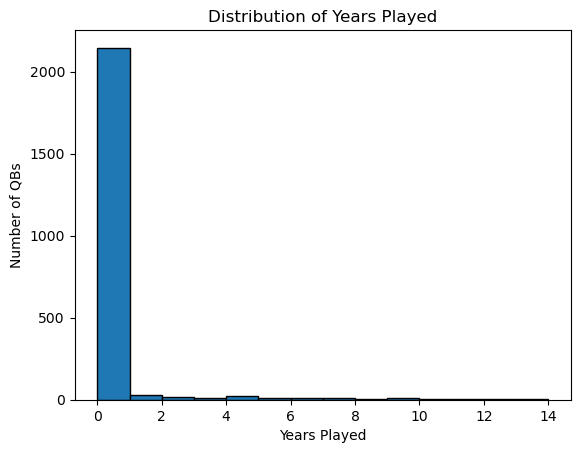

In [282]:
plt.hist(cfb_nfl_dataset['years_played'], bins=14, edgecolor='black')
plt.title("Distribution of Years Played")
plt.xlabel("Years Played")
plt.ylabel("Number of QBs")
plt.show()

From this plot, you can see that the vast majority of college quarterbacks do not make play in the NFL.

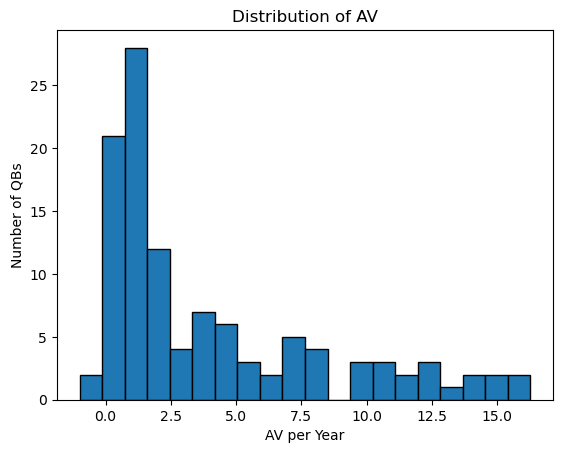

In [284]:
filtered_data = cfb_nfl_dataset["av_per_year"][cfb_nfl_dataset["av_per_year"] != 0]
plt.hist(filtered_data, bins=20, edgecolor='black')
plt.title("Distribution of AV")
plt.xlabel("AV per Year")
plt.ylabel("Number of QBs")
plt.show()

This plot shows that the majority of quarterbacks who do make the NFL do not make much of an impact.

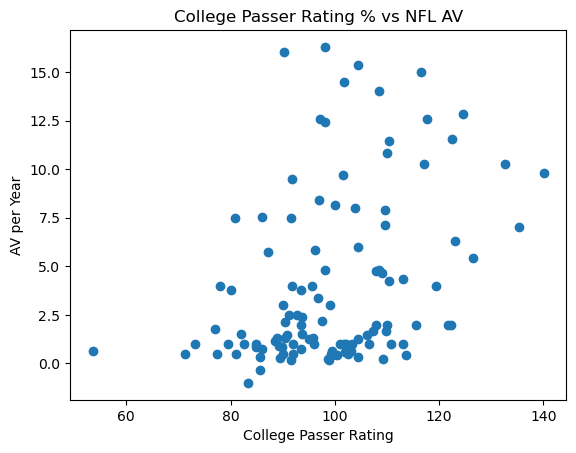

In [286]:
filtered_data = cfb_nfl_dataset[cfb_nfl_dataset["av_per_year"] != 0]
plt.scatter(filtered_data['passer_rating'], filtered_data['av_per_year'])
plt.title("College Passer Rating % vs NFL AV")
plt.xlabel("College Passer Rating")
plt.ylabel("AV per Year")
plt.show()

This scatter plot shows that there could be a small correlation between college passer rating and NFL success.

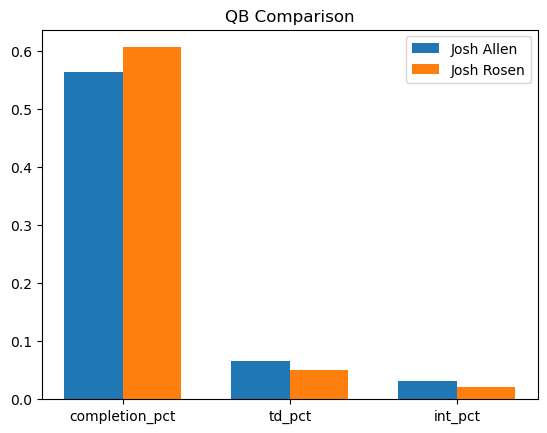

In [288]:
Allen = cfb_nfl_dataset[cfb_nfl_dataset["Clean_Name"] == "josh allen"].iloc[0]
Rosen = cfb_nfl_dataset[cfb_nfl_dataset["Clean_Name"] == "josh rosen"].iloc[0]

metrics = ['completion_pct', 'td_pct', 'int_pct']
values1 = [Allen[m] for m in metrics]
values2 = [Rosen[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, values1, width, label='Josh Allen')
plt.bar(x + width/2, values2, width, label='Josh Rosen')

plt.xticks(x, metrics)
plt.title("QB Comparison")
plt.legend()
plt.show()

However, this does not hold true when plotting some of the components of passer rating for two quarterbacks named Josh from the 2019 draft. Allen just won the MVP, while Rosen is a notorious bust. Surprisingly, Rosen seems the better prospect based on two key statistics: percentage of passes that were caught and percentage of passes that were intercepted (lower is better). We have to go beyond statistics to solve this issue.

# Next Steps
1. Pick variables to use similarity search, what combinations of college stats, combine stats, and school/conference data should I use?
2. Look into adding data such as college coach, wins in college, or college awards.
3. Explore and pick an algorithm for simlarity search.
4. Look into implementing clustering as a useful tool.
5. Compare analysis to actual quarterback success metric.
6. Interpret results, visualize data, and try some analysis of prospects from years not covered in data.

# Citations
1. ChatGPT Query: "How do I aggregate a column when grouping rows in a pandas dataframe by a unique ID that has multiple values per ID. I want to keep each value and alphabetize it, separated by commas."